## Phase A: Project Setup and Dataset Overview

In [144]:
from pathlib import Path
import sys

# Phase A: Make the project root importable inside the notebook
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

C:\Users\farha\code\nasa-spacecraft-telemetry


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import (
    build_channel_inventory,
    load_channel_array,
    load_channel_pair,
    load_labels_metadata,
)

from src.config import WINDOW_SIZE, WINDOW_STRIDE
from src.data.windowing import (
    create_sliding_windows,
    create_window_index_table,
    window_channel_array,
)

from src.data.labeling import (
    find_overlapping_intervals,
    intervals_overlap,
    label_single_window,
    label_windows,
    normalize_anomaly_intervals,
)

from src.data.preprocess import (
    build_scaler,
    fit_channel_scaler,
    preprocess_channel_pair,
    transform_channel_array,
)

from src.features.feature_engineering import (
    build_window_feature_dataframe,
    extract_features_from_single_window,
    extract_features_from_windows,
    generate_feature_names,
)

from src.data.pipeline import (
    build_channel_supervised_data,
    build_channel_unsupervised_data,
    summarize_channel_processed_data,
)

from src.data.dataset_builder import (
    build_supervised_dataset,
    build_unsupervised_dataset,
    get_channel_ids,
)

from src.data.splitting import (
    apply_channel_split_to_feature_df,
    create_outer_channel_split,
    summarize_outer_split,
)

from src.models.tuning import (
    create_group_kfold_splits,
    get_fold_data,
    prepare_supervised_model_data,
    summarize_group_kfold_splits,
)

from src.models.random_forest import (
    get_random_forest_feature_importance,
    run_random_forest_grouped_cv,
    train_random_forest_final_model,
)

from src.models.xgboost_model import (
    get_xgboost_feature_importance,
    run_xgboost_grouped_cv,
    train_xgboost_final_model,
)

from src.evaluation.thresholding import (
    build_model_comparison_table,
    build_threshold_grid,
    evaluate_scores_with_threshold,
    evaluate_threshold_grid,
    select_best_threshold,
)

from src.models.isolation_forest import run_isolation_forest_dev_test_pipeline
from src.evaluation.reporting import (
    build_paper_comparison_table,
    build_threshold_summary_table,
    plot_model_metric_comparison,
    plot_threshold_metric_curve,
    round_numeric_columns,
    save_dataframe_csv,
)

In [ ]:
# Load the metadata file that maps each channel to its anomaly intervals and spacecraft source
# This metadata is needed later to align raw telemetry channels with anomaly labels
labels_df = load_labels_metadata()
labels_df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [ ]:
# Checkss that the list like columns were parsed correctly
print(type(labels_df.loc[0, "anomaly_sequences"]))
print(type(labels_df.loc[0, "class"]))

labels_df.loc[0, ["chan_id", "spacecraft", "anomaly_sequences", "class", "num_values"]]

<class 'list'>
<class 'list'>


chan_id                                                     P-1
spacecraft                                                 SMAP
anomaly_sequences    [[2149, 2349], [4536, 4844], [3539, 3779]]
class                      [contextual, contextual, contextual]
num_values                                                 8505
Name: 0, dtype: object

## Phase B. Raw Telemetry Inspection

In [ ]:
# Build an inventory of all labelled channels so we can inspect what raw files exist
# This helps verify that each metadata entry has matching train and test telemetry files
inventory_df = build_channel_inventory(labels_df)
inventory_df.head()

,chan_id,spacecraft,anomaly_sequences,class,num_values,train_exists,test_exists,num_anomaly_intervals,num_anomaly_classes
0,C-1,MSL,"[[550, 750], [2100, 2210]]","[point, contextual]",2264,True,True,2,2
1,C-2,MSL,"[[290, 390], [1540, 1575]]","[point, contextual]",2051,True,True,2,2
2,D-14,MSL,"[[1630, 1650], [1800, 2000]]","[point, point]",2625,True,True,2,2
3,D-15,MSL,"[[1500, 2140]]",[point],2158,True,True,1,1
4,D-16,MSL,"[[600, 1250]]",[contextual],2191,True,True,1,1


In [149]:
# Confirms whether any files are missing
inventory_df[["train_exists", "test_exists"]].value_counts()

train_exists  test_exists
True          True           82
Name: count, dtype: int64

## Phase C. Sliding Window Construction

In [150]:
# Picks one channel and load its train/test arrays
sample_chan = inventory_df.loc[0, "chan_id"]
sample_data = load_channel_pair(sample_chan)

print("Channel:", sample_chan)
print("Train shape:", sample_data["train"].shape)
print("Test shape:", sample_data["test"].shape)
print("Train dtype:", sample_data["train"].dtype)
print("Test dtype:", sample_data["test"].dtype)

Channel: C-1
Train shape: (2264, 55)
Test shape: (2264, 55)
Train dtype: float64
Test dtype: float64


In [151]:
# Looks at the first few telemetry values
print("Train first 10 values:", sample_data["train"][:10])
print("Test first 10 values:", sample_data["test"][:10])

Train first 10 values: [[-0.94695788  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.94227769  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.         

In [152]:
# Checks whether metadata length matches the loaded test array length
row = labels_df[labels_df["chan_id"] == sample_chan].iloc[0]

print("Metadata num_values:", row["num_values"])
print("Actual test length:", len(sample_data["test"]))

Metadata num_values: 2264
Actual test length: 2264


In [ ]:
# Select one sample channel to inspect the raw telemetry format before building the full pipeline
# Makes it easier to understand the shape of the train and test arrays
sample_chan = inventory_df.loc[0, "chan_id"]
sample_data = load_channel_pair(sample_chan)

sample_train = sample_data["train"]
sample_test = sample_data["test"]

print("Sample channel:", sample_chan)
print("Train shape:", sample_train.shape)
print("Test shape:", sample_test.shape)

Sample channel: C-1
Train shape: (2264, 55)
Test shape: (2264, 55)


In [ ]:
# Split the continuous telemetry sequence into overlapping fixed-length windows
# These windows become the basic samples used later for labelling and feature extraction
train_windows = create_sliding_windows(
    array=sample_train,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
)

print("Window tensor shape:", train_windows.shape)
print("One window shape:", train_windows[0].shape)

Window tensor shape: (447, 30, 55)
One window shape: (30, 55)


In [ ]:
# Store the start and end index of each window so every window stays linked to its original time range
train_window_df = create_window_index_table(
    n_timesteps=sample_train.shape[0],
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    chan_id=sample_chan,
    split="train",
)

train_window_df.head()

,chan_id,split,window_id,start_idx,end_idx
0,C-1,train,0,0,29
1,C-1,train,1,5,34
2,C-1,train,2,10,39
3,C-1,train,3,15,44
4,C-1,train,4,20,49


In [156]:
windows_2, window_df_2 = window_channel_array(
    array=sample_train,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    chan_id=sample_chan,
    split="train",
)

print("Windows shape:", windows_2.shape)
print("Window table shape:", window_df_2.shape)
print("Counts match:", len(windows_2) == len(window_df_2))

Windows shape: (447, 30, 55)
Window table shape: (447, 5)
Counts match: True


In [157]:
window_df_2.head(10)

,chan_id,split,window_id,start_idx,end_idx
0,C-1,train,0,0,29
1,C-1,train,1,5,34
2,C-1,train,2,10,39
3,C-1,train,3,15,44
4,C-1,train,4,20,49
5,C-1,train,5,25,54
6,C-1,train,6,30,59
7,C-1,train,7,35,64
8,C-1,train,8,40,69
9,C-1,train,9,45,74


In [ ]:
# Verify that the generated window matches the corresponding slice from the original raw sequence
# This confirms that window construction is correctly aligned with the source telemetry
start_idx = window_df_2.loc[0, "start_idx"]
end_idx = window_df_2.loc[0, "end_idx"]

print("First window indices:", start_idx, end_idx)
print("Original slice shape:", sample_train[start_idx:end_idx + 1].shape)
print("Stored window shape:", windows_2[0].shape)

np.allclose(sample_train[start_idx:end_idx + 1], windows_2[0])

First window indices: 0 29
Original slice shape: (30, 55)
Stored window shape: (30, 55)


True

## Phase D. Window-Level Labelling

In [ ]:
# Retrieve the anomaly intervals for the sample channel from the metadata table
# These intervals are later used to convert raw anomaly ranges into window-level labels
sample_row = labels_df[labels_df["chan_id"] == sample_chan].iloc[0]
sample_intervals = normalize_anomaly_intervals(sample_row["anomaly_sequences"])

print("Sample channel:", sample_chan)
print("Anomaly intervals:", sample_intervals)

Sample channel: C-1
Anomaly intervals: [(550, 750), (2100, 2210)]


In [160]:
# Quick overlap sanity checks
print(intervals_overlap(0, 29, 550, 750))      # expected: False
print(intervals_overlap(540, 569, 550, 750))   # expected: True
print(intervals_overlap(751, 780, 550, 750))   # expected: False

False
True
False


In [161]:
# Test one specific window by hand
example_label = label_single_window(
    window_start=540,
    window_end=569,
    anomaly_intervals=sample_intervals,
)

example_label

{'label': 1,
 'has_overlap': True,
 'num_overlapping_intervals': 1,
 'overlapping_intervals': [(550, 750)]}

In [162]:
labeled_train_window_df = label_windows(
    window_df=train_window_df,
    anomaly_intervals=sample_row["anomaly_sequences"],
)

labeled_train_window_df.head(15)

,chan_id,split,window_id,start_idx,end_idx,label,has_overlap,num_overlapping_intervals,overlapping_intervals
0,C-1,train,0,0,29,0,False,0,[]
1,C-1,train,1,5,34,0,False,0,[]
2,C-1,train,2,10,39,0,False,0,[]
3,C-1,train,3,15,44,0,False,0,[]
4,C-1,train,4,20,49,0,False,0,[]
5,C-1,train,5,25,54,0,False,0,[]
6,C-1,train,6,30,59,0,False,0,[]
7,C-1,train,7,35,64,0,False,0,[]
8,C-1,train,8,40,69,0,False,0,[]
9,C-1,train,9,45,74,0,False,0,[]


In [163]:
labeled_train_window_df["label"].value_counts().sort_index()

label
0    373
1     74
Name: count, dtype: int64

In [164]:
# Look at windows that were labeled anomalous
labeled_train_window_df[labeled_train_window_df["label"] == 1].head(10)

,chan_id,split,window_id,start_idx,end_idx,label,has_overlap,num_overlapping_intervals,overlapping_intervals
105,C-1,train,105,525,554,1,True,1,"[(550, 750)]"
106,C-1,train,106,530,559,1,True,1,"[(550, 750)]"
107,C-1,train,107,535,564,1,True,1,"[(550, 750)]"
108,C-1,train,108,540,569,1,True,1,"[(550, 750)]"
109,C-1,train,109,545,574,1,True,1,"[(550, 750)]"
110,C-1,train,110,550,579,1,True,1,"[(550, 750)]"
111,C-1,train,111,555,584,1,True,1,"[(550, 750)]"
112,C-1,train,112,560,589,1,True,1,"[(550, 750)]"
113,C-1,train,113,565,594,1,True,1,"[(550, 750)]"
114,C-1,train,114,570,599,1,True,1,"[(550, 750)]"


In [165]:
# Check the first anomalous window
first_anom = labeled_train_window_df[labeled_train_window_df["label"] == 1].iloc[0]
first_anom

chan_id                               C-1
split                               train
window_id                             105
start_idx                             525
end_idx                               554
label                                   1
has_overlap                          True
num_overlapping_intervals               1
overlapping_intervals        [(550, 750)]
Name: 105, dtype: object

In [166]:
print("First anomalous window start/end:", first_anom["start_idx"], first_anom["end_idx"])
print("Overlapping intervals:", first_anom["overlapping_intervals"])

First anomalous window start/end: 525 554
Overlapping intervals: [(550, 750)]


## Phase E. Channel-Wise Preprocessing

In [ ]:
# Fit the scaler on the training sequence only, then apply it to both train and test
SCALER_NAME = "standard"

In [168]:
sample_chan = inventory_df.loc[0, "chan_id"]
sample_data = load_channel_pair(sample_chan)

sample_train = sample_data["train"]
sample_test = sample_data["test"]

scaled_data = preprocess_channel_pair(
    train_array=sample_train,
    test_array=sample_test,
    scaler_name=SCALER_NAME,
)

train_scaled = scaled_data["train_scaled"]
test_scaled = scaled_data["test_scaled"]

print("Sample channel:", sample_chan)
print("Original train shape:", sample_train.shape)
print("Scaled train shape:", train_scaled.shape)
print("Original test shape:", sample_test.shape)
print("Scaled test shape:", test_scaled.shape)

Sample channel: C-1
Original train shape: (2264, 55)
Scaled train shape: (2264, 55)
Original test shape: (2264, 55)
Scaled test shape: (2264, 55)


In [169]:
print("Original train first row (first 10 values):")
print(sample_train[0, :10])

print("\nScaled train first row (first 10 values):")
print(train_scaled[0, :10])

Original train first row (first 10 values):
[-0.94695788  0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]

Scaled train first row (first 10 values):
[-0.83021519  0.          0.          0.          0.         -0.31043202
  0.         -0.04207032  0.         -0.02102121]


In [170]:
train_feature_means = train_scaled.mean(axis=0)
train_feature_stds = train_scaled.std(axis=0)

print("First 10 feature means after scaling:")
print(np.round(train_feature_means[:10], 6))

print("\nFirst 10 feature stds after scaling:")
print(np.round(train_feature_stds[:10], 6))

num_constant_features = int(np.sum(np.isclose(train_feature_stds, 0.0)))
print("Number of constant features in the sample train array:", num_constant_features)

First 10 feature means after scaling:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

First 10 feature stds after scaling:
[1. 0. 0. 0. 0. 1. 0. 1. 0. 1.]
Number of constant features in the sample train array: 39


In [171]:
print("Train and scaled train same shape:", sample_train.shape == train_scaled.shape)
print("Test and scaled test same shape:", sample_test.shape == test_scaled.shape)
print("Any NaNs in scaled train:", np.isnan(train_scaled).any())
print("Any NaNs in scaled test:", np.isnan(test_scaled).any())

Train and scaled train same shape: True
Test and scaled test same shape: True
Any NaNs in scaled train: False
Any NaNs in scaled test: False


## Phase F. Feature Engineering

In [ ]:
# Use a test window here because anomaly labels are aligned with the test sequence in this benchmark
# Start with one window so we can inspect the engineered statistics before extracting features at scale
sample_chan = inventory_df.loc[0, "chan_id"]
sample_data = load_channel_pair(sample_chan)

scaled_data = preprocess_channel_pair(
    train_array=sample_data["train"],
    test_array=sample_data["test"],
    scaler_name=SCALER_NAME,
)

test_scaled = scaled_data["test_scaled"]

test_windows, test_window_df = window_channel_array(
    array=test_scaled,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    chan_id=sample_chan,
    split="test",
)

sample_row = labels_df[labels_df["chan_id"] == sample_chan].iloc[0]

labeled_test_window_df = label_windows(
    window_df=test_window_df,
    anomaly_intervals=sample_row["anomaly_sequences"],
)

print("Test window tensor shape:", test_windows.shape)
print("Labeled test window table shape:", labeled_test_window_df.shape)

Test window tensor shape: (447, 30, 55)
Labeled test window table shape: (447, 9)


In [173]:
single_window_features = extract_features_from_single_window(test_windows[0])

print("Single window feature vector shape:", single_window_features.shape)
print("First 20 feature values:")
print(np.round(single_window_features[:20], 6))

Single window feature vector shape: (660,)
First 20 feature values:
[-0.880722  0.        0.        0.        0.        0.395918  0.
 -0.04207   0.       -0.021021  0.        0.285833  0.134006  0.
  0.        0.        0.        0.        0.       -0.047046]


In [174]:
feature_matrix, feature_names = extract_features_from_windows(test_windows)

print("Feature matrix shape:", feature_matrix.shape)
print("Number of feature names:", len(feature_names))
print("First 10 feature names:", feature_names[:10])

Feature matrix shape: (447, 660)
Number of feature names: 660
First 10 feature names: ['mean_v0', 'mean_v1', 'mean_v2', 'mean_v3', 'mean_v4', 'mean_v5', 'mean_v6', 'mean_v7', 'mean_v8', 'mean_v9']


In [175]:
test_feature_df = build_window_feature_dataframe(
    windows=test_windows,
    window_df=labeled_test_window_df,
)

print("Feature dataframe shape:", test_feature_df.shape)
test_feature_df.iloc[:5, :15]

Feature dataframe shape: (447, 669)


,chan_id,split,window_id,start_idx,end_idx,label,has_overlap,num_overlapping_intervals,overlapping_intervals,mean_v0,mean_v1,mean_v2,mean_v3,mean_v4,mean_v5
0,C-1,test,0,0,29,0,False,0,[],-0.880722,0.0,0.0,0.0,0.0,0.395918
1,C-1,test,1,5,34,0,False,0,[],-0.883432,0.0,0.0,0.0,0.0,0.513643
2,C-1,test,2,10,39,0,False,0,[],-0.876903,0.0,0.0,0.0,0.0,0.513643
3,C-1,test,3,15,44,0,False,0,[],-0.875056,0.0,0.0,0.0,0.0,0.395918
4,C-1,test,4,20,49,0,False,0,[],-0.875795,0.0,0.0,0.0,0.0,0.395918


In [176]:
print("Label counts:")
print(test_feature_df["label"].value_counts().sort_index())

Label counts:
label
0    373
1     74
Name: count, dtype: int64


In [177]:
feature_only_cols = [col for col in test_feature_df.columns if col not in labeled_test_window_df.columns]

print("Number of feature columns:", len(feature_only_cols))
print("First 10 feature columns:", feature_only_cols[:10])

# Sanity check: no NaNs in engineered features
print("Any NaNs in feature columns:", test_feature_df[feature_only_cols].isna().any().any())

Number of feature columns: 660
First 10 feature columns: ['mean_v0', 'mean_v1', 'mean_v2', 'mean_v3', 'mean_v4', 'mean_v5', 'mean_v6', 'mean_v7', 'mean_v8', 'mean_v9']
Any NaNs in feature columns: False


## Phase G. End-to-End Channel Pipeline Validation

In [178]:
sample_chan = inventory_df.loc[0, "chan_id"]

channel_unsup = build_channel_unsupervised_data(
    chan_id=sample_chan,
    labels_df=labels_df,
)

summarize_channel_processed_data(channel_unsup)

{'chan_id': 'C-1',
 'spacecraft': 'MSL',
 'n_train_windows': 447,
 'n_test_windows': 447,
 'n_test_anomalous_windows': 74}

In [ ]:
# Run the full supervised pipeline for one channel: preprocessing, windowing, labelling, and feature extraction
# end-to-end validation before scaling up to the full dataset
channel_sup = build_channel_supervised_data(
    chan_id=sample_chan,
    labels_df=labels_df,
)

summarize_channel_processed_data(channel_sup)

{'chan_id': 'C-1',
 'spacecraft': 'MSL',
 'n_supervised_windows': 447,
 'n_supervised_anomalous_windows': 74}

In [180]:
print("Unsupervised train feature df shape:", channel_unsup["train_feature_df"].shape)
print("Unsupervised test feature df shape:", channel_unsup["test_feature_df"].shape)

print("\nSupervised feature df shape:", channel_sup["supervised_feature_df"].shape)

Unsupervised train feature df shape: (447, 665)
Unsupervised test feature df shape: (447, 669)

Supervised feature df shape: (447, 669)


In [181]:
channel_sup["supervised_feature_df"].head()

,chan_id,split,window_id,start_idx,end_idx,label,has_overlap,num_overlapping_intervals,overlapping_intervals,mean_v0,...,kurtosis_v45,kurtosis_v46,kurtosis_v47,kurtosis_v48,kurtosis_v49,kurtosis_v50,kurtosis_v51,kurtosis_v52,kurtosis_v53,kurtosis_v54
0,C-1,test,0,0,29,0,False,0,[],-0.880722,...,-2.148148,0.0,12.206633,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,C-1,test,1,5,34,0,False,0,[],-0.883432,...,-2.148148,0.0,12.206633,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,C-1,test,2,10,39,0,False,0,[],-0.876903,...,-2.148148,0.0,12.206633,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,C-1,test,3,15,44,0,False,0,[],-0.875056,...,-2.148148,0.0,12.206633,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C-1,test,4,20,49,0,False,0,[],-0.875795,...,-2.148148,0.0,12.206633,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [182]:
channel_sup["supervised_feature_df"]["label"].value_counts().sort_index()

label
0    373
1     74
Name: count, dtype: int64

## Phase H. MSL Dataset Assembly

In [ ]:
# Assemble the full labelled supervised dataset for all MSL channels
# Combines window-level features from multiple channels into one benchmark-ready feature table
msl_supervised = build_supervised_dataset(
    labels_df=labels_df,
    spacecraft="MSL",
)

print("Combined supervised feature df shape:", msl_supervised["feature_df"].shape)
print("Channel summary shape:", msl_supervised["channel_summary_df"].shape)
print("Number of MSL channels:", len(msl_supervised["chan_ids"]))

Combined supervised feature df shape: (14601, 670)
Channel summary shape: (27, 5)
Number of MSL channels: 27


In [184]:
msl_supervised["channel_summary_df"].head()

,chan_id,spacecraft,n_windows,n_anomalous_windows,anomaly_ratio
0,C-1,MSL,447,74,0.165548
1,C-2,MSL,405,39,0.096296
2,D-14,MSL,520,56,0.107692
3,D-15,MSL,426,131,0.307512
4,D-16,MSL,433,136,0.314088


In [185]:
print("Supervised label counts:")
print(msl_supervised["feature_df"]["label"].value_counts().sort_index())

print("\nUnique channels:", msl_supervised["feature_df"]["chan_id"].nunique())
print("Unique spacecraft values:", msl_supervised["feature_df"]["spacecraft"].unique())

Supervised label counts:
label
0    12853
1     1748
Name: count, dtype: int64

Unique channels: 27
Unique spacecraft values: <StringArray>
['MSL']
Length: 1, dtype: str


In [ ]:
# Build separate train and test feature tables for the unsupervised baseline
# Isolation Forest is fitted on train windows and evaluated on labelled test windows
msl_unsupervised = build_unsupervised_dataset(
    labels_df=labels_df,
    spacecraft="MSL",
)

print("Combined unsupervised train shape:", msl_unsupervised["train_feature_df"].shape)
print("Combined unsupervised test shape:", msl_unsupervised["test_feature_df"].shape)
print("Unsupervised channel summary shape:", msl_unsupervised["channel_summary_df"].shape)

Combined unsupervised train shape: (14601, 666)
Combined unsupervised test shape: (14601, 670)
Unsupervised channel summary shape: (27, 6)


In [187]:
msl_unsupervised["channel_summary_df"].head()

,chan_id,spacecraft,n_train_windows,n_test_windows,n_test_anomalous_windows,test_anomaly_ratio
0,C-1,MSL,447,447,74,0.165548
1,C-2,MSL,405,405,39,0.096296
2,D-14,MSL,520,520,56,0.107692
3,D-15,MSL,426,426,131,0.307512
4,D-16,MSL,433,433,136,0.314088


In [188]:
print("Unsupervised test label counts:")
print(msl_unsupervised["test_feature_df"]["label"].value_counts().sort_index())

print("\nUnique test channels:", msl_unsupervised["test_feature_df"]["chan_id"].nunique())
print("Unique spacecraft values:", msl_unsupervised["test_feature_df"]["spacecraft"].unique())

Unsupervised test label counts:
label
0    12853
1     1748
Name: count, dtype: int64

Unique test channels: 27
Unique spacecraft values: <StringArray>
['MSL']
Length: 1, dtype: str


## Phase I. Strict Channel-Level Splitting for MSL

In [ ]:
# Split channels, not individual windows, so train and test remain fully disjoint at the channel level
# Creates a stricter and more leakage-resistant evaluation setting
msl_outer_split = create_outer_channel_split(
    channel_summary_df=msl_supervised["channel_summary_df"],
    test_size=0.2,
)

print("Used stratification:", msl_outer_split["used_stratification"])
print("Number of dev channels:", len(msl_outer_split["dev_chan_ids"]))
print("Number of test channels:", len(msl_outer_split["test_chan_ids"]))
print("Dev channels:", msl_outer_split["dev_chan_ids"])
print("Test channels:", msl_outer_split["test_chan_ids"])

Used stratification: True
Number of dev channels: 21
Number of test channels: 6
Dev channels: ['C-1', 'C-2', 'D-14', 'D-16', 'F-4', 'F-5', 'F-8', 'M-2', 'M-3', 'M-4', 'M-5', 'M-6', 'M-7', 'P-11', 'P-14', 'P-15', 'T-13', 'T-4', 'T-5', 'T-8', 'T-9']
Test channels: ['D-15', 'F-7', 'M-1', 'P-10', 'S-2', 'T-12']


In [190]:
msl_outer_split["split_summary_df"].head(10)

,chan_id,spacecraft,n_windows,n_anomalous_windows,anomaly_ratio,outer_split
0,C-1,MSL,447,74,0.165548,dev
1,C-2,MSL,405,39,0.096296,dev
2,D-14,MSL,520,56,0.107692,dev
3,D-15,MSL,426,131,0.307512,test
4,D-16,MSL,433,136,0.314088,dev
5,F-4,MSL,679,20,0.029455,dev
6,F-5,MSL,779,36,0.046213,dev
7,F-7,MSL,1005,102,0.101493,test
8,F-8,MSL,492,107,0.217480,dev
9,M-1,MSL,450,233,0.517778,test


In [191]:
msl_supervised_split = apply_channel_split_to_feature_df(
    feature_df=msl_supervised["feature_df"],
    dev_chan_ids=msl_outer_split["dev_chan_ids"],
    test_chan_ids=msl_outer_split["test_chan_ids"],
)

print("Dev feature df shape:", msl_supervised_split["dev_df"].shape)
print("Test feature df shape:", msl_supervised_split["test_df"].shape)

Dev feature df shape: (10664, 670)
Test feature df shape: (3937, 670)


In [192]:
print("Dev label counts:")
print(msl_supervised_split["dev_df"]["label"].value_counts().sort_index())

print("\nTest label counts:")
print(msl_supervised_split["test_df"]["label"].value_counts().sort_index())

Dev label counts:
label
0    9452
1    1212
Name: count, dtype: int64

Test label counts:
label
0    3401
1     536
Name: count, dtype: int64


In [193]:
split_summary = summarize_outer_split(
    split_summary_df=msl_outer_split["split_summary_df"],
    dev_df=msl_supervised_split["dev_df"],
    test_df=msl_supervised_split["test_df"],
)

split_summary

{'n_dev_channels': 21,
 'n_test_channels': 6,
 'mean_dev_anomaly_ratio': 0.1271036730658412,
 'mean_test_anomaly_ratio': 0.1729519642220613,
 'n_dev_windows': 10664,
 'n_test_windows': 3937,
 'n_dev_anomalous_windows': 1212,
 'n_test_anomalous_windows': 536}

In [194]:
dev_channels = set(msl_supervised_split["dev_df"]["chan_id"].unique())
test_channels = set(msl_supervised_split["test_df"]["chan_id"].unique())

print("Channel overlap:", dev_channels & test_channels)
print("Dev unique channels:", len(dev_channels))
print("Test unique channels:", len(test_channels))

Channel overlap: set()
Dev unique channels: 21
Test unique channels: 6


## Phase J. Cross-Validation Preparation for MSL

In [ ]:
# Use grouped cross-validation so windows from the same channel do not appear in both train and validation folds
# Prevents overly optimistic validation results caused by correlated windows
msl_cv = create_group_kfold_splits(
    feature_df=msl_supervised_split["dev_df"],
    n_splits=4,
)

print("X shape:", msl_cv["X"].shape)
print("y shape:", msl_cv["y"].shape)
print("groups shape:", msl_cv["groups"].shape)
print("Number of feature columns:", len(msl_cv["feature_cols"]))
print("Number of folds:", len(msl_cv["fold_indices"]))

X shape: (10664, 660)
y shape: (10664,)
groups shape: (10664,)
Number of feature columns: 660
Number of folds: 4


In [196]:
fold_summary_df = summarize_group_kfold_splits(
    feature_df=msl_supervised_split["dev_df"],
    fold_indices=msl_cv["fold_indices"],
)

fold_summary_df

,fold_id,n_train_rows,n_val_rows,n_train_channels,n_val_channels,train_anomalous_rows,val_anomalous_rows,train_anomaly_ratio,val_anomaly_ratio,channel_overlap_count
0,0,7832,2832,16,5,901,311,0.115041,0.109816,0
1,1,8118,2546,16,5,913,299,0.112466,0.117439,0
2,2,7915,2749,15,6,932,280,0.117751,0.101855,0
3,3,8127,2537,16,5,890,322,0.109512,0.126922,0


In [197]:
fold0 = get_fold_data(
    X=msl_cv["X"],
    y=msl_cv["y"],
    groups=msl_cv["groups"],
    fold_indices=msl_cv["fold_indices"],
    fold_id=0,
)

print("Fold 0 train shape:", fold0["X_train"].shape)
print("Fold 0 val shape:", fold0["X_val"].shape)
print("Fold 0 train anomaly count:", int(fold0["y_train"].sum()))
print("Fold 0 val anomaly count:", int(fold0["y_val"].sum()))
print("Fold 0 train unique channels:", len(set(fold0["groups_train"])))
print("Fold 0 val unique channels:", len(set(fold0["groups_val"])))
print("Fold 0 channel overlap:", set(fold0["groups_train"]) & set(fold0["groups_val"]))

Fold 0 train shape: (7832, 660)
Fold 0 val shape: (2832, 660)
Fold 0 train anomaly count: 901
Fold 0 val anomaly count: 311
Fold 0 train unique channels: 16
Fold 0 val unique channels: 5
Fold 0 channel overlap: set()


In [198]:
print("First 10 feature columns:")
print(msl_cv["feature_cols"][:10])

First 10 feature columns:
['mean_v0', 'mean_v1', 'mean_v2', 'mean_v3', 'mean_v4', 'mean_v5', 'mean_v6', 'mean_v7', 'mean_v8', 'mean_v9']


## Phase K. Random Forest Experiments on MSL

In [ ]:
# Define the Random Forest configuration used across the grouped cross-validation and final training stages
rf_params = {
    "n_estimators": 300,
    "max_depth": None,
    "min_samples_leaf": 2,
    "class_weight": "balanced_subsample",
    "n_jobs": -1,
}

In [ ]:
# Train and evaluate Random Forest using grouped cross-validation on the development channels
# The out-of-fold scores from this step are later used for threshold tuning
rf_cv_results = run_random_forest_grouped_cv(
    dev_df=msl_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=rf_params,
)

rf_cv_results["fold_metrics_df"]

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous,fold_id,n_train_rows,n_val_rows,n_train_channels,n_val_channels
0,0.5,0.491071,0.176849,0.260047,0.319928,0.760943,55,57,2464,256,2832,311,0,7832,2832,16,5
1,0.5,0.741573,0.220736,0.340206,0.506292,0.817491,66,23,2224,233,2546,299,1,8118,2546,16,5
2,0.5,0.339623,0.321429,0.330275,0.363942,0.751915,90,175,2294,190,2749,280,2,7915,2749,15,6
3,0.5,0.431373,0.068323,0.117962,0.253069,0.762772,22,29,2186,300,2537,322,3,8127,2537,16,5


In [201]:
print("Mean CV metrics:")
rf_cv_results["mean_metrics"]

print("Std CV metrics:")
rf_cv_results["std_metrics"]

Mean CV metrics:
Std CV metrics:


{'precision': 0.17210903751102366,
 'recall': 0.10489612282121538,
 'f1': 0.10251549194318595,
 'pr_auc': 0.10716708325944327,
 'roc_auc': 0.02985358625598647}

In [202]:
rf_final_results = train_random_forest_final_model(
    dev_df=msl_supervised_split["dev_df"],
    test_df=msl_supervised_split["test_df"],
    threshold=0.5,
    model_params=rf_params,
)

rf_final_results["test_metrics"]

{'threshold': 0.5,
 'precision': 0.3008658008658009,
 'recall': 0.2593283582089552,
 'f1': 0.2785571142284569,
 'pr_auc': 0.30354526006081234,
 'roc_auc': 0.7264580325365235,
 'tp': 139,
 'fp': 323,
 'tn': 3078,
 'fn': 397,
 'n_rows': 3937,
 'n_anomalous': 536}

In [203]:
rf_importance_df = get_random_forest_feature_importance(
    model=rf_final_results["model"],
    feature_cols=rf_final_results["feature_cols"],
)

rf_importance_df.head(20)

,feature,importance
0,max_v0,0.054350
1,rms_v0,0.050637
2,std_diff_v0,0.044553
3,var_v0,0.041621
4,mean_abs_diff_v0,0.039619
5,median_v0,0.035302
6,mean_v0,0.035269
7,std_v0,0.034352
8,min_v0,0.032532
9,slope_v0,0.015241


## Phase L. XGBoost Experiments on MSL

In [ ]:
# Define the XGBoost configuration, including class weighting to help with anomaly imbalance
# These parameters are reused for both cross-validation and final model fitting
xgb_params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "max_depth": 6,
    "min_child_weight": 1.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "n_jobs": -1,
}

In [ ]:
# Train and evaluate XGBoost using the same grouped fold structure as Random Forest
# Keeps the comparison fair by using the same development split design
xgb_cv_results = run_xgboost_grouped_cv(
    dev_df=msl_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=xgb_params,
)

xgb_cv_results["fold_metrics_df"]

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous,fold_id,n_train_rows,n_val_rows,n_train_channels,n_val_channels,scale_pos_weight
0,0.5,0.457143,0.257235,0.329218,0.337129,0.754904,80,95,2426,231,2832,311,0,7832,2832,16,5,7.692564
1,0.5,0.431159,0.397993,0.413913,0.390882,0.720300,119,157,2090,180,2546,299,1,8118,2546,16,5,7.891566
2,0.5,0.189522,0.439286,0.264801,0.214029,0.708883,123,526,1943,157,2749,280,2,7915,2749,15,6,7.492489
3,0.5,0.326241,0.142857,0.198704,0.240309,0.725592,46,95,2120,276,2537,322,3,8127,2537,16,5,8.131461


In [206]:
print("Mean CV metrics:")
xgb_cv_results["mean_metrics"]

print("Std CV metrics:")
xgb_cv_results["std_metrics"]

Mean CV metrics:
Std CV metrics:


{'precision': 0.12162767382931962,
 'recall': 0.13561809050748866,
 'f1': 0.09186712820471521,
 'pr_auc': 0.08269284734564747,
 'roc_auc': 0.01960451122576843}

In [207]:
xgb_final_results = train_xgboost_final_model(
    dev_df=msl_supervised_split["dev_df"],
    test_df=msl_supervised_split["test_df"],
    threshold=0.5,
    model_params=xgb_params,
)

xgb_final_results["test_metrics"]

{'threshold': 0.5,
 'precision': 0.1865558912386707,
 'recall': 0.4608208955223881,
 'f1': 0.26559139784946234,
 'pr_auc': 0.2529376877286542,
 'roc_auc': 0.7095095494301501,
 'tp': 247,
 'fp': 1077,
 'tn': 2324,
 'fn': 289,
 'n_rows': 3937,
 'n_anomalous': 536}

In [208]:
print("Final scale_pos_weight:", xgb_final_results["scale_pos_weight"])

xgb_importance_df = get_xgboost_feature_importance(
    model=xgb_final_results["model"],
    feature_cols=xgb_final_results["feature_cols"],
)

xgb_importance_df.head(20)

Final scale_pos_weight: 7.798679867986799


,feature,importance
0,min_v33,0.033072
1,min_v11,0.032206
2,min_v31,0.029131
3,median_v11,0.022851
4,min_v6,0.019508
5,std_v6,0.016246
6,median_v20,0.016121
7,var_v6,0.015283
8,std_diff_v0,0.013776
9,min_v5,0.010871


## Phase M. Threshold Tuning and Supervised Comparison on MSL

In [209]:
rf_cv_results = run_random_forest_grouped_cv(
    dev_df=msl_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=rf_params,
)

xgb_cv_results = run_xgboost_grouped_cv(
    dev_df=msl_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=xgb_params,
)

print("RF OOF shape:", rf_cv_results["oof_prediction_df"].shape)
print("XGB OOF shape:", xgb_cv_results["oof_prediction_df"].shape)

RF OOF shape: (10664, 14)
XGB OOF shape: (10664, 14)


In [ ]:
# Create a grid of possible decision thresholds instead of assuming 0.5 is optimal
# This is important because anomaly score distributions differ across models
threshold_grid = build_threshold_grid(
    start=0.05,
    stop=0.95,
    step=0.05,
)

threshold_grid

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

In [ ]:
# Evaluate model performance across many thresholds using development-set scores
# The threshold with the best F1 is selected and then applied once to held-out test channels
rf_threshold_df = evaluate_threshold_grid(
    y_true=rf_cv_results["oof_prediction_df"]["y_true"].to_numpy(),
    y_score=rf_cv_results["oof_prediction_df"]["y_score"].to_numpy(),
    thresholds=threshold_grid,
)

rf_best_threshold = select_best_threshold(
    threshold_metrics_df=rf_threshold_df,
    metric="f1",
)

print("RF best threshold row:")
rf_best_threshold

RF best threshold row:


{'threshold': 0.25,
 'precision': 0.2665045170257123,
 'recall': 0.6328382838283828,
 'f1': 0.3750611246943765,
 'pr_auc': 0.33811808523853193,
 'roc_auc': 0.7643961708908936,
 'tp': 767.0,
 'fp': 2111.0,
 'tn': 7341.0,
 'fn': 445.0,
 'n_rows': 10664.0,
 'n_anomalous': 1212.0}

In [212]:
xgb_threshold_df = evaluate_threshold_grid(
    y_true=xgb_cv_results["oof_prediction_df"]["y_true"].to_numpy(),
    y_score=xgb_cv_results["oof_prediction_df"]["y_score"].to_numpy(),
    thresholds=threshold_grid,
)

xgb_best_threshold = select_best_threshold(
    threshold_metrics_df=xgb_threshold_df,
    metric="f1",
)

print("XGB best threshold row:")
xgb_best_threshold

XGB best threshold row:


{'threshold': 0.3,
 'precision': 0.24730631092868138,
 'recall': 0.3976897689768977,
 'f1': 0.304966782663714,
 'pr_auc': 0.2769590052482419,
 'roc_auc': 0.7123203010102112,
 'tp': 482.0,
 'fp': 1467.0,
 'tn': 7985.0,
 'fn': 730.0,
 'n_rows': 10664.0,
 'n_anomalous': 1212.0}

In [213]:
print("Top RF thresholds by F1:")
rf_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

Top RF thresholds by F1:


,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
4,0.25,0.266505,0.632838,0.375061,0.338118,0.764396,767,2111,7341,445,10664,1212
3,0.20,0.227273,0.730198,0.346651,0.338118,0.764396,885,3009,6443,327,10664,1212
5,0.30,0.268259,0.481848,0.344644,0.338118,0.764396,584,1593,7859,628,10664,1212
6,0.35,0.280122,0.377888,0.321742,0.338118,0.764396,458,1177,8275,754,10664,1212
7,0.40,0.316848,0.311881,0.314345,0.338118,0.764396,378,815,8637,834,10664,1212
2,0.15,0.186517,0.821782,0.304029,0.338118,0.764396,996,4344,5108,216,10664,1212
8,0.45,0.359006,0.238449,0.286564,0.338118,0.764396,289,516,8936,923,10664,1212
9,0.50,0.450677,0.192244,0.269520,0.338118,0.764396,233,284,9168,979,10664,1212
1,0.10,0.151779,0.936469,0.261220,0.338118,0.764396,1135,6343,3109,77,10664,1212
10,0.55,0.518732,0.148515,0.230917,0.338118,0.764396,180,167,9285,1032,10664,1212


In [214]:
print("Top XGB thresholds by F1:")
xgb_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

Top XGB thresholds by F1:


,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
5,0.30,0.247306,0.397690,0.304967,0.276959,0.71232,482,1467,7985,730,10664,1212
11,0.60,0.329756,0.278878,0.302190,0.276959,0.71232,338,687,8765,874,10664,1212
9,0.50,0.296535,0.303630,0.300041,0.276959,0.71232,368,873,8579,844,10664,1212
12,0.65,0.342887,0.266502,0.299907,0.276959,0.71232,323,619,8833,889,10664,1212
10,0.55,0.310559,0.288779,0.299273,0.276959,0.71232,350,777,8675,862,10664,1212
8,0.45,0.281958,0.318482,0.299109,0.276959,0.71232,386,983,8469,826,10664,1212
1,0.10,0.194472,0.644389,0.298776,0.276959,0.71232,781,3235,6217,431,10664,1212
7,0.40,0.268824,0.335809,0.298606,0.276959,0.71232,407,1107,8345,805,10664,1212
6,0.35,0.252461,0.359736,0.296700,0.276959,0.71232,436,1291,8161,776,10664,1212
2,0.15,0.202699,0.545380,0.295551,0.276959,0.71232,661,2600,6852,551,10664,1212


In [ ]:
# Retrain Random Forest on the full development set after threshold selection is complete
rf_final_results = train_random_forest_final_model(
    dev_df=msl_supervised_split["dev_df"],
    test_df=msl_supervised_split["test_df"],
    threshold=0.5,
    model_params=rf_params,
)
# Retrain XGBoost on the full development set after threshold tuning
xgb_final_results = train_xgboost_final_model(
    dev_df=msl_supervised_split["dev_df"],
    test_df=msl_supervised_split["test_df"],
    threshold=0.5,
    model_params=xgb_params,
)

In [216]:
rf_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=rf_final_results["test_prediction_df"]["y_true"].to_numpy(),
    y_score=rf_final_results["test_prediction_df"]["y_score"].to_numpy(),
    threshold=rf_best_threshold["threshold"],
)

xgb_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=xgb_final_results["test_prediction_df"]["y_true"].to_numpy(),
    y_score=xgb_final_results["test_prediction_df"]["y_score"].to_numpy(),
    threshold=xgb_best_threshold["threshold"],
)

print("RF tuned test metrics:")
print(rf_tuned_test_metrics)

print("\nXGB tuned test metrics:")
print(xgb_tuned_test_metrics)

RF tuned test metrics:
{'threshold': 0.25, 'precision': 0.21069019200830305, 'recall': 0.7574626865671642, 'f1': 0.32967925294356476, 'pr_auc': 0.30354526006081234, 'roc_auc': 0.7264580325365235, 'tp': 406, 'fp': 1521, 'tn': 1880, 'fn': 130, 'n_rows': 3937, 'n_anomalous': 536}

XGB tuned test metrics:
{'threshold': 0.3, 'precision': 0.21049692908989392, 'recall': 0.7033582089552238, 'f1': 0.3240223463687151, 'pr_auc': 0.2529376877286542, 'roc_auc': 0.7095095494301501, 'tp': 377, 'fp': 1414, 'tn': 1987, 'fn': 159, 'n_rows': 3937, 'n_anomalous': 536}


In [217]:
comparison_df = build_model_comparison_table(
    [
        {
            "model": "Random Forest",
            "dev_selection_metric": "f1",
            "dev_best_threshold": rf_best_threshold["threshold"],
            "dev_precision": rf_best_threshold["precision"],
            "dev_recall": rf_best_threshold["recall"],
            "dev_f1": rf_best_threshold["f1"],
            "dev_pr_auc": rf_best_threshold["pr_auc"],
            "dev_roc_auc": rf_best_threshold["roc_auc"],
            "test_precision": rf_tuned_test_metrics["precision"],
            "test_recall": rf_tuned_test_metrics["recall"],
            "test_f1": rf_tuned_test_metrics["f1"],
            "test_pr_auc": rf_tuned_test_metrics["pr_auc"],
            "test_roc_auc": rf_tuned_test_metrics["roc_auc"],
            "test_tp": rf_tuned_test_metrics["tp"],
            "test_fp": rf_tuned_test_metrics["fp"],
            "test_tn": rf_tuned_test_metrics["tn"],
            "test_fn": rf_tuned_test_metrics["fn"],
        },
        {
            "model": "XGBoost",
            "dev_selection_metric": "f1",
            "dev_best_threshold": xgb_best_threshold["threshold"],
            "dev_precision": xgb_best_threshold["precision"],
            "dev_recall": xgb_best_threshold["recall"],
            "dev_f1": xgb_best_threshold["f1"],
            "dev_pr_auc": xgb_best_threshold["pr_auc"],
            "dev_roc_auc": xgb_best_threshold["roc_auc"],
            "test_precision": xgb_tuned_test_metrics["precision"],
            "test_recall": xgb_tuned_test_metrics["recall"],
            "test_f1": xgb_tuned_test_metrics["f1"],
            "test_pr_auc": xgb_tuned_test_metrics["pr_auc"],
            "test_roc_auc": xgb_tuned_test_metrics["roc_auc"],
            "test_tp": xgb_tuned_test_metrics["tp"],
            "test_fp": xgb_tuned_test_metrics["fp"],
            "test_tn": xgb_tuned_test_metrics["tn"],
            "test_fn": xgb_tuned_test_metrics["fn"],
        },
    ]
)

comparison_df

,model,dev_selection_metric,dev_best_threshold,dev_precision,dev_recall,dev_f1,dev_pr_auc,dev_roc_auc,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc,test_tp,test_fp,test_tn,test_fn
0,Random Forest,f1,0.25,0.266505,0.632838,0.375061,0.338118,0.764396,0.210690,0.757463,0.329679,0.303545,0.726458,406,1521,1880,130
1,XGBoost,f1,0.30,0.247306,0.397690,0.304967,0.276959,0.712320,0.210497,0.703358,0.324022,0.252938,0.709510,377,1414,1987,159


## Phase N. Isolation Forest Experiments on MSL

In [218]:
msl_unsupervised_train_split = apply_channel_split_to_feature_df(
    feature_df=msl_unsupervised["train_feature_df"],
    dev_chan_ids=msl_outer_split["dev_chan_ids"],
    test_chan_ids=msl_outer_split["test_chan_ids"],
)

msl_unsupervised_test_split = apply_channel_split_to_feature_df(
    feature_df=msl_unsupervised["test_feature_df"],
    dev_chan_ids=msl_outer_split["dev_chan_ids"],
    test_chan_ids=msl_outer_split["test_chan_ids"],
)

print("Dev train shape:", msl_unsupervised_train_split["dev_df"].shape)
print("Held-out train shape:", msl_unsupervised_train_split["test_df"].shape)
print("Dev labeled test shape:", msl_unsupervised_test_split["dev_df"].shape)
print("Held-out labeled test shape:", msl_unsupervised_test_split["test_df"].shape)

Dev train shape: (10664, 666)
Held-out train shape: (3937, 666)
Dev labeled test shape: (10664, 670)
Held-out labeled test shape: (3937, 670)


In [219]:
if_params = {
    "n_estimators": 300,
    "max_samples": "auto",
    "max_features": 1.0,
    "bootstrap": False,
    "contamination": "auto",
    "n_jobs": -1,
}

In [ ]:
# Fit Isolation Forest without using anomaly labels, then tune its threshold on development outputs
# This provides an unsupervised baseline under the same feature-engineered framework
if_results = run_isolation_forest_dev_test_pipeline(
    dev_train_df=msl_unsupervised_train_split["dev_df"],
    dev_test_df=msl_unsupervised_test_split["dev_df"],
    heldout_test_df=msl_unsupervised_test_split["test_df"],
    model_params=if_params,
)

print("Dev score df shape:", if_results["dev_score_df"].shape)
print("Held-out test score df shape:", if_results["test_score_df"].shape)
print("Score normalizer:", if_results["score_normalizer"])

Dev score df shape: (10664, 12)
Held-out test score df shape: (3937, 12)
Score normalizer: {'score_min': -0.1720345925261989, 'score_max': 0.11512788163222976}


In [221]:
if_threshold_df = evaluate_threshold_grid(
    y_true=if_results["dev_score_df"]["label"].to_numpy(),
    y_score=if_results["dev_score_df"]["score"].to_numpy(),
    thresholds=threshold_grid,
)

if_best_threshold = select_best_threshold(
    threshold_metrics_df=if_threshold_df,
    metric="f1",
)

print("Isolation Forest best threshold row:")
if_best_threshold

Isolation Forest best threshold row:


{'threshold': 0.05,
 'precision': 0.12950425857174055,
 'recall': 0.9785478547854786,
 'f1': 0.2287367405978785,
 'pr_auc': 0.13868161787145528,
 'roc_auc': 0.5681258283995984,
 'tp': 1186.0,
 'fp': 7972.0,
 'tn': 1480.0,
 'fn': 26.0,
 'n_rows': 10664.0,
 'n_anomalous': 1212.0}

In [222]:
if_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
0,0.05,0.129504,0.978548,0.228737,0.138682,0.568126,1186,7972,1480,26,10664,1212
1,0.10,0.123719,0.797030,0.214191,0.138682,0.568126,966,6842,2610,246,10664,1212
4,0.25,0.147525,0.376238,0.211945,0.138682,0.568126,456,2635,6817,756,10664,1212
2,0.15,0.123632,0.624587,0.206408,0.138682,0.568126,757,5366,4086,455,10664,1212
3,0.20,0.125258,0.501650,0.200462,0.138682,0.568126,608,4246,5206,604,10664,1212
5,0.30,0.142055,0.271452,0.186508,0.138682,0.568126,329,1987,7465,883,10664,1212
6,0.35,0.146313,0.209571,0.172320,0.138682,0.568126,254,1482,7970,958,10664,1212
7,0.40,0.139307,0.152640,0.145669,0.138682,0.568126,185,1143,8309,1027,10664,1212
8,0.45,0.142439,0.120462,0.130532,0.138682,0.568126,146,879,8573,1066,10664,1212
9,0.50,0.142265,0.084983,0.106405,0.138682,0.568126,103,621,8831,1109,10664,1212


In [223]:
if_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=if_results["test_score_df"]["label"].to_numpy(),
    y_score=if_results["test_score_df"]["score"].to_numpy(),
    threshold=if_best_threshold["threshold"],
)

print("Isolation Forest tuned test metrics:")
if_tuned_test_metrics

Isolation Forest tuned test metrics:


{'threshold': 0.05,
 'precision': 0.14087142475273992,
 'recall': 0.9832089552238806,
 'f1': 0.2464344166471826,
 'pr_auc': 0.11620801315334614,
 'roc_auc': 0.3937592981871004,
 'tp': 527,
 'fp': 3214,
 'tn': 187,
 'fn': 9,
 'n_rows': 3937,
 'n_anomalous': 536}

In [224]:
comparison_with_if_df = build_model_comparison_table(
    [
        {
            "model": "Random Forest",
            "dev_selection_metric": "f1",
            "dev_best_threshold": rf_best_threshold["threshold"],
            "dev_precision": rf_best_threshold["precision"],
            "dev_recall": rf_best_threshold["recall"],
            "dev_f1": rf_best_threshold["f1"],
            "dev_pr_auc": rf_best_threshold["pr_auc"],
            "dev_roc_auc": rf_best_threshold["roc_auc"],
            "test_precision": rf_tuned_test_metrics["precision"],
            "test_recall": rf_tuned_test_metrics["recall"],
            "test_f1": rf_tuned_test_metrics["f1"],
            "test_pr_auc": rf_tuned_test_metrics["pr_auc"],
            "test_roc_auc": rf_tuned_test_metrics["roc_auc"],
            "test_tp": rf_tuned_test_metrics["tp"],
            "test_fp": rf_tuned_test_metrics["fp"],
            "test_tn": rf_tuned_test_metrics["tn"],
            "test_fn": rf_tuned_test_metrics["fn"],
        },
        {
            "model": "XGBoost",
            "dev_selection_metric": "f1",
            "dev_best_threshold": xgb_best_threshold["threshold"],
            "dev_precision": xgb_best_threshold["precision"],
            "dev_recall": xgb_best_threshold["recall"],
            "dev_f1": xgb_best_threshold["f1"],
            "dev_pr_auc": xgb_best_threshold["pr_auc"],
            "dev_roc_auc": xgb_best_threshold["roc_auc"],
            "test_precision": xgb_tuned_test_metrics["precision"],
            "test_recall": xgb_tuned_test_metrics["recall"],
            "test_f1": xgb_tuned_test_metrics["f1"],
            "test_pr_auc": xgb_tuned_test_metrics["pr_auc"],
            "test_roc_auc": xgb_tuned_test_metrics["roc_auc"],
            "test_tp": xgb_tuned_test_metrics["tp"],
            "test_fp": xgb_tuned_test_metrics["fp"],
            "test_tn": xgb_tuned_test_metrics["tn"],
            "test_fn": xgb_tuned_test_metrics["fn"],
        },
        {
            "model": "Isolation Forest",
            "dev_selection_metric": "f1",
            "dev_best_threshold": if_best_threshold["threshold"],
            "dev_precision": if_best_threshold["precision"],
            "dev_recall": if_best_threshold["recall"],
            "dev_f1": if_best_threshold["f1"],
            "dev_pr_auc": if_best_threshold["pr_auc"],
            "dev_roc_auc": if_best_threshold["roc_auc"],
            "test_precision": if_tuned_test_metrics["precision"],
            "test_recall": if_tuned_test_metrics["recall"],
            "test_f1": if_tuned_test_metrics["f1"],
            "test_pr_auc": if_tuned_test_metrics["pr_auc"],
            "test_roc_auc": if_tuned_test_metrics["roc_auc"],
            "test_tp": if_tuned_test_metrics["tp"],
            "test_fp": if_tuned_test_metrics["fp"],
            "test_tn": if_tuned_test_metrics["tn"],
            "test_fn": if_tuned_test_metrics["fn"],
        },
    ]
)

comparison_with_if_df

,model,dev_selection_metric,dev_best_threshold,dev_precision,dev_recall,dev_f1,dev_pr_auc,dev_roc_auc,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc,test_tp,test_fp,test_tn,test_fn
0,Random Forest,f1,0.25,0.266505,0.632838,0.375061,0.338118,0.764396,0.210690,0.757463,0.329679,0.303545,0.726458,406,1521,1880,130
1,XGBoost,f1,0.30,0.247306,0.397690,0.304967,0.276959,0.712320,0.210497,0.703358,0.324022,0.252938,0.709510,377,1414,1987,159
2,Isolation Forest,f1,0.05,0.129504,0.978548,0.228737,0.138682,0.568126,0.140871,0.983209,0.246434,0.116208,0.393759,527,3214,187,9


## Phase O. Reporting and Saved Outputs for MSL

In [225]:
PROJECT_RESULTS_DIR = Path("results")
METRICS_DIR = PROJECT_RESULTS_DIR / "metrics"
PLOTS_DIR = PROJECT_RESULTS_DIR / "plots"

METRICS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(METRICS_DIR.resolve())
print(PLOTS_DIR.resolve())

C:\Users\farha\code\nasa-spacecraft-telemetry\notebooks\results\metrics
C:\Users\farha\code\nasa-spacecraft-telemetry\notebooks\results\plots


In [226]:
paper_comparison_df = build_paper_comparison_table(comparison_with_if_df)
paper_comparison_df = round_numeric_columns(paper_comparison_df, decimals=4)

paper_comparison_df

,model,dev_best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc,test_tp,test_fp,test_tn,test_fn
0,Random Forest,0.25,0.2107,0.7575,0.3297,0.3035,0.7265,406,1521,1880,130
1,XGBoost,0.30,0.2105,0.7034,0.3240,0.2529,0.7095,377,1414,1987,159
2,Isolation Forest,0.05,0.1409,0.9832,0.2464,0.1162,0.3938,527,3214,187,9


In [227]:
threshold_summary_df = build_threshold_summary_table(
    {
        "Random Forest": rf_threshold_df,
        "XGBoost": xgb_threshold_df,
        "Isolation Forest": if_threshold_df,
    }
)

threshold_summary_df = round_numeric_columns(threshold_summary_df, decimals=4)
threshold_summary_df

,model,best_threshold,dev_precision,dev_recall,dev_f1,dev_pr_auc,dev_roc_auc
0,Random Forest,0.25,0.2665,0.6328,0.3751,0.3381,0.7644
1,XGBoost,0.30,0.2473,0.3977,0.3050,0.2770,0.7123
2,Isolation Forest,0.05,0.1295,0.9785,0.2287,0.1387,0.5681


In [228]:
save_dataframe_csv(
    comparison_with_if_df,
    METRICS_DIR / "full_model_comparison.csv",
)

save_dataframe_csv(
    paper_comparison_df,
    METRICS_DIR / "paper_model_comparison.csv",
)

save_dataframe_csv(
    threshold_summary_df,
    METRICS_DIR / "threshold_summary.csv",
)

save_dataframe_csv(
    round_numeric_columns(rf_threshold_df, 4),
    METRICS_DIR / "rf_threshold_sweep.csv",
)

save_dataframe_csv(
    round_numeric_columns(xgb_threshold_df, 4),
    METRICS_DIR / "xgb_threshold_sweep.csv",
)

save_dataframe_csv(
    round_numeric_columns(if_threshold_df, 4),
    METRICS_DIR / "if_threshold_sweep.csv",
)

print("Saved key metric tables.")

Saved key metric tables.


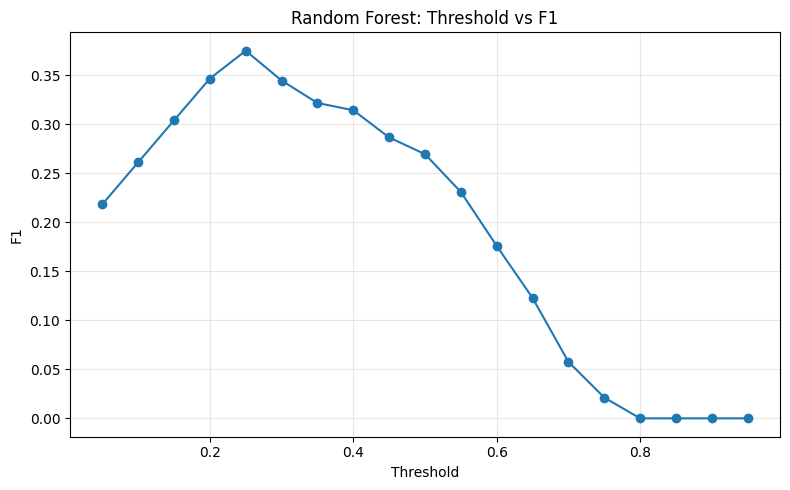

In [ ]:
# Plot the threshold-performance relationship so the selected operating point can be visualised clearly
plot_threshold_metric_curve(
    threshold_df=rf_threshold_df,
    metric="f1",
    title="Random Forest: Threshold vs F1",
    output_path=PLOTS_DIR / "rf_threshold_vs_f1.png",
)

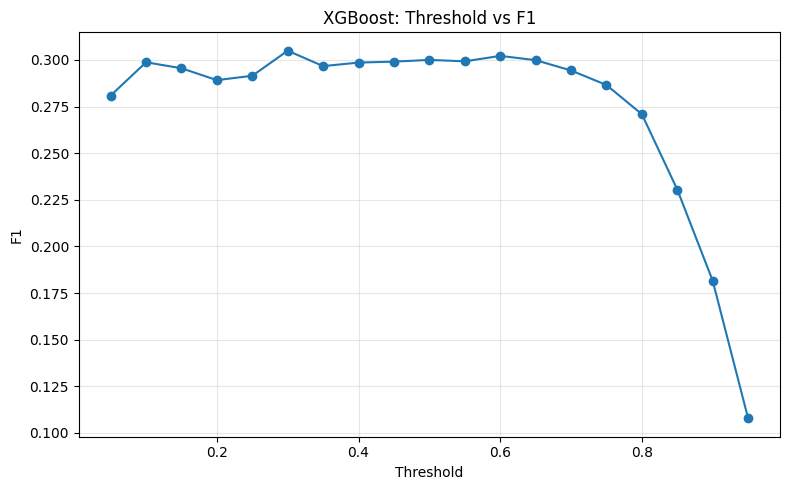

In [230]:
plot_threshold_metric_curve(
    threshold_df=xgb_threshold_df,
    metric="f1",
    title="XGBoost: Threshold vs F1",
    output_path=PLOTS_DIR / "xgb_threshold_vs_f1.png",
)

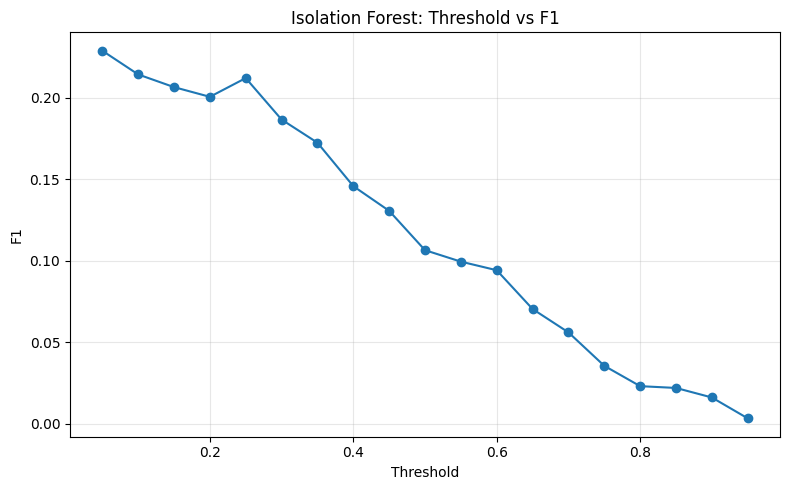

In [231]:
plot_threshold_metric_curve(
    threshold_df=if_threshold_df,
    metric="f1",
    title="Isolation Forest: Threshold vs F1",
    output_path=PLOTS_DIR / "if_threshold_vs_f1.png",
)

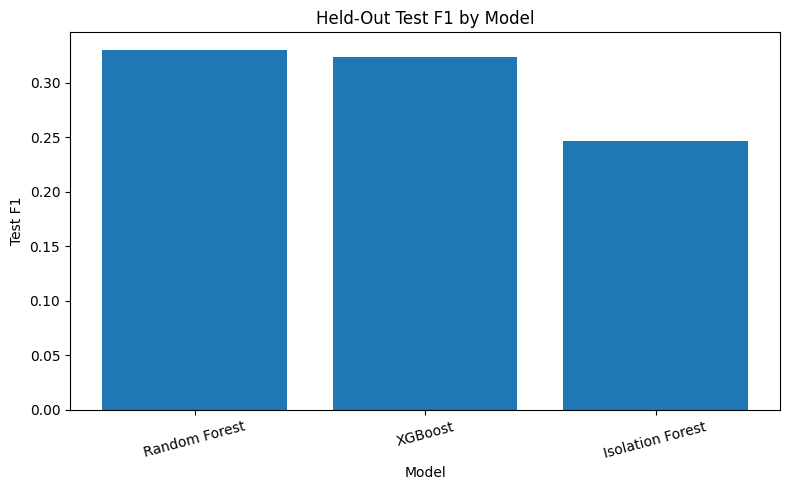

In [232]:
plot_model_metric_comparison(
    comparison_df=paper_comparison_df,
    metric="test_f1",
    title="Held-Out Test F1 by Model",
    output_path=PLOTS_DIR / "test_f1_by_model.png",
)

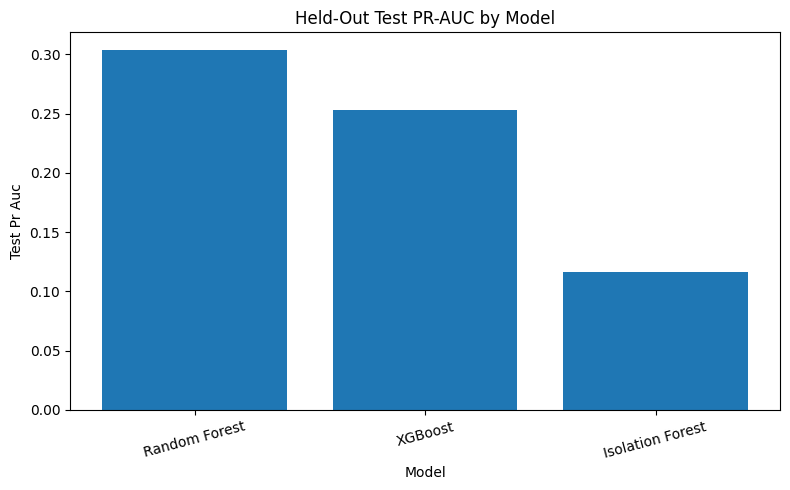

In [233]:
plot_model_metric_comparison(
    comparison_df=paper_comparison_df,
    metric="test_pr_auc",
    title="Held-Out Test PR-AUC by Model",
    output_path=PLOTS_DIR / "test_pr_auc_by_model.png",
)

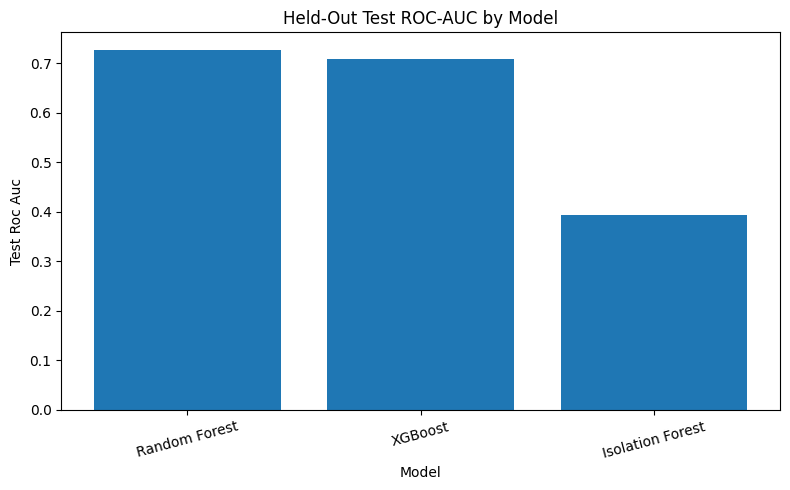

In [234]:
plot_model_metric_comparison(
    comparison_df=paper_comparison_df,
    metric="test_roc_auc",
    title="Held-Out Test ROC-AUC by Model",
    output_path=PLOTS_DIR / "test_roc_auc_by_model.png",
)

In [235]:
print("Saved metric files:")
for path in sorted(METRICS_DIR.glob("*")):
    print(path.name)

print("\nSaved plot files:")
for path in sorted(PLOTS_DIR.glob("*")):
    print(path.name)

Saved metric files:
combined_smap_msl_model_comparison.csv
full_model_comparison.csv
if_threshold_sweep.csv
paper_model_comparison.csv
rf_threshold_sweep.csv
threshold_summary.csv
xgb_threshold_sweep.csv

Saved plot files:
if_threshold_vs_f1.png
rf_threshold_vs_f1.png
test_f1_by_model.png
test_pr_auc_by_model.png
test_roc_auc_by_model.png
xgb_threshold_vs_f1.png


## Phase P. SMAP Replication of the Strict Pipeline

In [236]:
smap_supervised = build_supervised_dataset(
    labels_df=labels_df,
    spacecraft="SMAP",
)

smap_unsupervised = build_unsupervised_dataset(
    labels_df=labels_df,
    spacecraft="SMAP",
)

print("SMAP supervised feature df shape:", smap_supervised["feature_df"].shape)
print("SMAP supervised channel summary shape:", smap_supervised["channel_summary_df"].shape)
print("Number of SMAP channels:", len(smap_supervised["chan_ids"]))

print("\nSMAP unsupervised train shape:", smap_unsupervised["train_feature_df"].shape)
print("SMAP unsupervised test shape:", smap_unsupervised["test_feature_df"].shape)
print("SMAP unsupervised channel summary shape:", smap_unsupervised["channel_summary_df"].shape)

SMAP supervised feature df shape: (86873, 310)
SMAP supervised channel summary shape: (54, 5)
Number of SMAP channels: 54

SMAP unsupervised train shape: (86873, 306)
SMAP unsupervised test shape: (86873, 310)
SMAP unsupervised channel summary shape: (54, 6)


In [237]:
print("SMAP supervised label counts:")
print(smap_supervised["feature_df"]["label"].value_counts().sort_index())

print("\nUnique SMAP channels:", smap_supervised["feature_df"]["chan_id"].nunique())
print("Unique spacecraft values:", smap_supervised["feature_df"]["spacecraft"].unique())

SMAP supervised label counts:
label
0    75342
1    11531
Name: count, dtype: int64

Unique SMAP channels: 54
Unique spacecraft values: <StringArray>
['SMAP']
Length: 1, dtype: str


In [238]:
smap_outer_split = create_outer_channel_split(
    channel_summary_df=smap_supervised["channel_summary_df"],
    test_size=0.2,
)

print("Used stratification:", smap_outer_split["used_stratification"])
print("Number of dev channels:", len(smap_outer_split["dev_chan_ids"]))
print("Number of test channels:", len(smap_outer_split["test_chan_ids"]))
print("Dev channels:", smap_outer_split["dev_chan_ids"])
print("Test channels:", smap_outer_split["test_chan_ids"])

Used stratification: True
Number of dev channels: 43
Number of test channels: 11
Dev channels: ['A-1', 'A-2', 'A-4', 'A-5', 'A-6', 'A-7', 'A-9', 'B-1', 'D-1', 'D-11', 'D-12', 'D-2', 'D-4', 'D-6', 'D-8', 'D-9', 'E-1', 'E-10', 'E-11', 'E-12', 'E-13', 'E-2', 'E-3', 'E-4', 'E-5', 'E-8', 'F-1', 'F-2', 'F-3', 'G-1', 'G-2', 'G-4', 'G-6', 'G-7', 'P-1', 'P-2', 'P-3', 'P-4', 'P-7', 'R-1', 'S-1', 'T-1', 'T-3']
Test channels: ['A-3', 'A-8', 'D-13', 'D-3', 'D-5', 'D-7', 'E-6', 'E-7', 'E-9', 'G-3', 'T-2']


In [239]:
smap_supervised_split = apply_channel_split_to_feature_df(
    feature_df=smap_supervised["feature_df"],
    dev_chan_ids=smap_outer_split["dev_chan_ids"],
    test_chan_ids=smap_outer_split["test_chan_ids"],
)

print("SMAP dev feature df shape:", smap_supervised_split["dev_df"].shape)
print("SMAP test feature df shape:", smap_supervised_split["test_df"].shape)

SMAP dev feature df shape: (69011, 310)
SMAP test feature df shape: (17862, 310)


In [240]:
print("SMAP dev label counts:")
print(smap_supervised_split["dev_df"]["label"].value_counts().sort_index())

print("\nSMAP test label counts:")
print(smap_supervised_split["test_df"]["label"].value_counts().sort_index())

SMAP dev label counts:
label
0    60070
1     8941
Name: count, dtype: int64

SMAP test label counts:
label
0    15272
1     2590
Name: count, dtype: int64


In [241]:
smap_split_summary = summarize_outer_split(
    split_summary_df=smap_outer_split["split_summary_df"],
    dev_df=smap_supervised_split["dev_df"],
    test_df=smap_supervised_split["test_df"],
)

dev_channels = set(smap_supervised_split["dev_df"]["chan_id"].unique())
test_channels = set(smap_supervised_split["test_df"]["chan_id"].unique())

print("SMAP split summary:")
print(smap_split_summary)

print("\nChannel overlap:", dev_channels & test_channels)
print("Dev unique channels:", len(dev_channels))
print("Test unique channels:", len(test_channels))

SMAP split summary:
{'n_dev_channels': 43, 'n_test_channels': 11, 'mean_dev_anomaly_ratio': 0.125104073240184, 'mean_test_anomaly_ratio': 0.1426098700559571, 'n_dev_windows': 69011, 'n_test_windows': 17862, 'n_dev_anomalous_windows': 8941, 'n_test_anomalous_windows': 2590}

Channel overlap: set()
Dev unique channels: 43
Test unique channels: 11


In [242]:
smap_unsupervised_train_split = apply_channel_split_to_feature_df(
    feature_df=smap_unsupervised["train_feature_df"],
    dev_chan_ids=smap_outer_split["dev_chan_ids"],
    test_chan_ids=smap_outer_split["test_chan_ids"],
)

smap_unsupervised_test_split = apply_channel_split_to_feature_df(
    feature_df=smap_unsupervised["test_feature_df"],
    dev_chan_ids=smap_outer_split["dev_chan_ids"],
    test_chan_ids=smap_outer_split["test_chan_ids"],
)

print("SMAP dev train shape:", smap_unsupervised_train_split["dev_df"].shape)
print("SMAP held-out train shape:", smap_unsupervised_train_split["test_df"].shape)
print("SMAP dev labeled test shape:", smap_unsupervised_test_split["dev_df"].shape)
print("SMAP held-out labeled test shape:", smap_unsupervised_test_split["test_df"].shape)

SMAP dev train shape: (69011, 306)
SMAP held-out train shape: (17862, 306)
SMAP dev labeled test shape: (69011, 310)
SMAP held-out labeled test shape: (17862, 310)


## Phase Q. Random Forest and XGBoost Experiments on SMAP

In [243]:
smap_rf_cv_results = run_random_forest_grouped_cv(
    dev_df=smap_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=rf_params,
)

smap_rf_cv_results["fold_metrics_df"]

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous,fold_id,n_train_rows,n_val_rows,n_train_channels,n_val_channels
0,0.5,0.320590,0.331140,0.325780,0.369333,0.749332,956,2026,12415,1931,17328,2887,0,51683,17328,32,11
1,0.5,0.257875,0.356459,0.299257,0.258052,0.694127,745,2144,13628,1345,17862,2090,1,51149,17862,32,11
2,0.5,0.174178,0.730315,0.281274,0.351774,0.821514,742,3518,12841,274,17375,1016,2,51636,17375,32,11
3,0.5,0.129826,0.154003,0.140884,0.227410,0.538321,454,3043,10455,2494,16446,2948,3,52565,16446,33,10


In [244]:
print("SMAP Random Forest mean CV metrics:")
smap_rf_cv_results["mean_metrics"]

print("SMAP Random Forest std CV metrics:")
smap_rf_cv_results["std_metrics"]

SMAP Random Forest mean CV metrics:
SMAP Random Forest std CV metrics:


{'precision': 0.08521034019403542,
 'recall': 0.24225538487589404,
 'f1': 0.0826563208317528,
 'pr_auc': 0.06953576364184648,
 'roc_auc': 0.12023747483273953}

In [245]:
smap_xgb_cv_results = run_xgboost_grouped_cv(
    dev_df=smap_supervised_split["dev_df"],
    n_splits=4,
    threshold=0.5,
    model_params=xgb_params,
)

smap_xgb_cv_results["fold_metrics_df"]

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous,fold_id,n_train_rows,n_val_rows,n_train_channels,n_val_channels,scale_pos_weight
0,0.5,0.282771,0.394527,0.329429,0.321853,0.643560,1139,2889,11552,1748,17328,2887,0,51683,17328,32,11,7.537000
1,0.5,0.167305,0.376077,0.231585,0.219663,0.632651,786,3912,11860,1304,17862,2090,1,51149,17862,32,11,6.465917
2,0.5,0.132855,0.784449,0.227227,0.402222,0.826803,797,5202,11157,219,17375,1016,2,51636,17375,32,11,5.515584
3,0.5,0.198463,0.394166,0.264001,0.333545,0.568407,1162,4693,8805,1786,16446,2948,3,52565,16446,33,10,7.771066


In [246]:
print("SMAP XGBoost mean CV metrics:")
smap_xgb_cv_results["mean_metrics"]

print("SMAP XGBoost std CV metrics:")
smap_xgb_cv_results["std_metrics"]

SMAP XGBoost mean CV metrics:
SMAP XGBoost std CV metrics:


{'precision': 0.0641459961484683,
 'recall': 0.1982833811424986,
 'f1': 0.04718878238165983,
 'pr_auc': 0.0753064774230212,
 'roc_auc': 0.11103128202639}

In [247]:
print("SMAP RF OOF shape:", smap_rf_cv_results["oof_prediction_df"].shape)
print("SMAP XGB OOF shape:", smap_xgb_cv_results["oof_prediction_df"].shape)

SMAP RF OOF shape: (69011, 14)
SMAP XGB OOF shape: (69011, 14)


In [248]:
smap_rf_threshold_df = evaluate_threshold_grid(
    y_true=smap_rf_cv_results["oof_prediction_df"]["y_true"].to_numpy(),
    y_score=smap_rf_cv_results["oof_prediction_df"]["y_score"].to_numpy(),
    thresholds=threshold_grid,
)

smap_rf_best_threshold = select_best_threshold(
    threshold_metrics_df=smap_rf_threshold_df,
    metric="f1",
)

print("SMAP RF best threshold row:")
smap_rf_best_threshold

SMAP RF best threshold row:


{'threshold': 0.45,
 'precision': 0.23139708072683943,
 'recall': 0.43440331059165643,
 'f1': 0.3019513332815051,
 'pr_auc': 0.2567046187824115,
 'roc_auc': 0.6753169386116972,
 'tp': 3884.0,
 'fp': 12901.0,
 'tn': 47169.0,
 'fn': 5057.0,
 'n_rows': 69011.0,
 'n_anomalous': 8941.0}

In [249]:
smap_xgb_threshold_df = evaluate_threshold_grid(
    y_true=smap_xgb_cv_results["oof_prediction_df"]["y_true"].to_numpy(),
    y_score=smap_xgb_cv_results["oof_prediction_df"]["y_score"].to_numpy(),
    thresholds=threshold_grid,
)

smap_xgb_best_threshold = select_best_threshold(
    threshold_metrics_df=smap_xgb_threshold_df,
    metric="f1",
)

print("SMAP XGB best threshold row:")
smap_xgb_best_threshold

SMAP XGB best threshold row:


{'threshold': 0.75,
 'precision': 0.2553307322384539,
 'recall': 0.3147298959847892,
 'f1': 0.2819356777877968,
 'pr_auc': 0.26748268575538775,
 'roc_auc': 0.6385791800853,
 'tp': 2814.0,
 'fp': 8207.0,
 'tn': 51863.0,
 'fn': 6127.0,
 'n_rows': 69011.0,
 'n_anomalous': 8941.0}

In [250]:
smap_rf_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
8,0.45,0.231397,0.434403,0.301951,0.256705,0.675317,3884,12901,47169,5057,69011,8941
7,0.40,0.208663,0.533945,0.300063,0.256705,0.675317,4774,18105,41965,4167,69011,8941
5,0.30,0.187873,0.717705,0.297793,0.256705,0.675317,6417,27739,32331,2524,69011,8941
6,0.35,0.193503,0.614249,0.294296,0.256705,0.675317,5492,22890,37180,3449,69011,8941
4,0.25,0.173667,0.802818,0.285561,0.256705,0.675317,7178,34154,25916,1763,69011,8941
3,0.20,0.164353,0.865899,0.276268,0.256705,0.675317,7742,39364,20706,1199,69011,8941
2,0.15,0.153961,0.947098,0.264865,0.256705,0.675317,8468,46533,13537,473,69011,8941
9,0.50,0.212577,0.324013,0.256724,0.256705,0.675317,2897,10731,49339,6044,69011,8941
1,0.10,0.146247,0.982888,0.254610,0.256705,0.675317,8788,51302,8768,153,69011,8941
0,0.05,0.135314,0.993401,0.238184,0.256705,0.675317,8882,56758,3312,59,69011,8941


In [251]:
smap_xgb_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
14,0.75,0.255331,0.314730,0.281936,0.267483,0.638579,2814,8207,51863,6127,69011,8941
15,0.80,0.266032,0.290460,0.277709,0.267483,0.638579,2597,7165,52905,6344,69011,8941
11,0.60,0.211755,0.391679,0.274893,0.267483,0.638579,3502,13036,47034,5439,69011,8941
10,0.55,0.203317,0.414048,0.272717,0.267483,0.638579,3702,14506,45564,5239,69011,8941
16,0.85,0.279928,0.259702,0.269436,0.267483,0.638579,2322,5973,54097,6619,69011,8941
9,0.50,0.188727,0.434403,0.263135,0.267483,0.638579,3884,16696,43374,5057,69011,8941
1,0.10,0.153867,0.899228,0.262771,0.267483,0.638579,8040,44213,15857,901,69011,8941
13,0.70,0.217095,0.330947,0.262195,0.267483,0.638579,2959,10671,49399,5982,69011,8941
3,0.20,0.159218,0.728330,0.261311,0.267483,0.638579,6512,34388,25682,2429,69011,8941
7,0.40,0.174532,0.516609,0.260916,0.267483,0.638579,4619,21846,38224,4322,69011,8941


In [252]:
smap_rf_final_results = train_random_forest_final_model(
    dev_df=smap_supervised_split["dev_df"],
    test_df=smap_supervised_split["test_df"],
    threshold=0.5,
    model_params=rf_params,
)

smap_xgb_final_results = train_xgboost_final_model(
    dev_df=smap_supervised_split["dev_df"],
    test_df=smap_supervised_split["test_df"],
    threshold=0.5,
    model_params=xgb_params,
)

In [253]:
smap_rf_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=smap_rf_final_results["test_prediction_df"]["y_true"].to_numpy(),
    y_score=smap_rf_final_results["test_prediction_df"]["y_score"].to_numpy(),
    threshold=smap_rf_best_threshold["threshold"],
)

smap_xgb_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=smap_xgb_final_results["test_prediction_df"]["y_true"].to_numpy(),
    y_score=smap_xgb_final_results["test_prediction_df"]["y_score"].to_numpy(),
    threshold=smap_xgb_best_threshold["threshold"],
)

print("SMAP RF tuned test metrics:")
print(smap_rf_tuned_test_metrics)

print("\nSMAP XGB tuned test metrics:")
print(smap_xgb_tuned_test_metrics)

SMAP RF tuned test metrics:
{'threshold': 0.45, 'precision': 0.38303099017384734, 'recall': 0.7826254826254826, 'f1': 0.5143364628266938, 'pr_auc': 0.6407018354997756, 'roc_auc': 0.8584451622167704, 'tp': 2027, 'fp': 3265, 'tn': 12007, 'fn': 563, 'n_rows': 17862, 'n_anomalous': 2590}

SMAP XGB tuned test metrics:
{'threshold': 0.75, 'precision': 0.5091575091575091, 'recall': 0.42934362934362935, 'f1': 0.46585672392124006, 'pr_auc': 0.5907141716231535, 'roc_auc': 0.8428178047088472, 'tp': 1112, 'fp': 1072, 'tn': 14200, 'fn': 1478, 'n_rows': 17862, 'n_anomalous': 2590}


## Phase R. Isolation Forest and Final SMAP Comparison

In [254]:
smap_if_results = run_isolation_forest_dev_test_pipeline(
    dev_train_df=smap_unsupervised_train_split["dev_df"],
    dev_test_df=smap_unsupervised_test_split["dev_df"],
    heldout_test_df=smap_unsupervised_test_split["test_df"],
    model_params=if_params,
)

print("SMAP IF dev score df shape:", smap_if_results["dev_score_df"].shape)
print("SMAP IF held-out test score df shape:", smap_if_results["test_score_df"].shape)
print("SMAP IF score normalizer:", smap_if_results["score_normalizer"])

SMAP IF dev score df shape: (69011, 12)
SMAP IF held-out test score df shape: (17862, 12)
SMAP IF score normalizer: {'score_min': -0.13029486173619959, 'score_max': 0.2370846604491733}


In [255]:
smap_if_threshold_df = evaluate_threshold_grid(
    y_true=smap_if_results["dev_score_df"]["label"].to_numpy(),
    y_score=smap_if_results["dev_score_df"]["score"].to_numpy(),
    thresholds=threshold_grid,
)

smap_if_best_threshold = select_best_threshold(
    threshold_metrics_df=smap_if_threshold_df,
    metric="f1",
)

print("SMAP Isolation Forest best threshold row:")
smap_if_best_threshold

SMAP Isolation Forest best threshold row:


{'threshold': 0.05,
 'precision': 0.14112592072956856,
 'recall': 0.9000111844312717,
 'f1': 0.24399266233077122,
 'pr_auc': 0.11647601967883153,
 'roc_auc': 0.4900072990190563,
 'tp': 8047.0,
 'fp': 48973.0,
 'tn': 11097.0,
 'fn': 894.0,
 'n_rows': 69011.0,
 'n_anomalous': 8941.0}

In [256]:
smap_if_threshold_df.sort_values(
    ["f1", "precision", "recall", "threshold"],
    ascending=[False, False, False, True],
).head(10)

,threshold,precision,recall,f1,pr_auc,roc_auc,tp,fp,tn,fn,n_rows,n_anomalous
0,0.05,0.141126,0.900011,0.243993,0.116476,0.490007,8047,48973,11097,894,69011,8941
1,0.10,0.147885,0.663572,0.241867,0.116476,0.490007,5933,34186,25884,3008,69011,8941
2,0.15,0.112546,0.346941,0.169959,0.116476,0.490007,3102,24460,35610,5839,69011,8941
3,0.20,0.066269,0.163852,0.094370,0.116476,0.490007,1465,20642,39428,7476,69011,8941
4,0.25,0.053903,0.094620,0.068680,0.116476,0.490007,846,14849,45221,8095,69011,8941
5,0.30,0.047185,0.057935,0.052011,0.116476,0.490007,518,10460,49610,8423,69011,8941
6,0.35,0.056064,0.038363,0.045554,0.116476,0.490007,343,5775,54295,8598,69011,8941
7,0.40,0.064371,0.030310,0.041214,0.116476,0.490007,271,3939,56131,8670,69011,8941
8,0.45,0.071744,0.023599,0.035516,0.116476,0.490007,211,2730,57340,8730,69011,8941
9,0.50,0.071807,0.016665,0.027052,0.116476,0.490007,149,1926,58144,8792,69011,8941


In [257]:
smap_if_tuned_test_metrics = evaluate_scores_with_threshold(
    y_true=smap_if_results["test_score_df"]["label"].to_numpy(),
    y_score=smap_if_results["test_score_df"]["score"].to_numpy(),
    threshold=smap_if_best_threshold["threshold"],
)

print("SMAP Isolation Forest tuned test metrics:")
smap_if_tuned_test_metrics

SMAP Isolation Forest tuned test metrics:


{'threshold': 0.05,
 'precision': 0.14500055984772142,
 'recall': 1.0,
 'f1': 0.25327596323097984,
 'pr_auc': 0.1081618335664592,
 'roc_auc': 0.3517542513515536,
 'tp': 2590,
 'fp': 15272,
 'tn': 0,
 'fn': 0,
 'n_rows': 17862,
 'n_anomalous': 2590}

In [258]:
smap_comparison_df = build_model_comparison_table(
    [
        {
            "model": "Random Forest",
            "dev_selection_metric": "f1",
            "dev_best_threshold": smap_rf_best_threshold["threshold"],
            "dev_precision": smap_rf_best_threshold["precision"],
            "dev_recall": smap_rf_best_threshold["recall"],
            "dev_f1": smap_rf_best_threshold["f1"],
            "dev_pr_auc": smap_rf_best_threshold["pr_auc"],
            "dev_roc_auc": smap_rf_best_threshold["roc_auc"],
            "test_precision": smap_rf_tuned_test_metrics["precision"],
            "test_recall": smap_rf_tuned_test_metrics["recall"],
            "test_f1": smap_rf_tuned_test_metrics["f1"],
            "test_pr_auc": smap_rf_tuned_test_metrics["pr_auc"],
            "test_roc_auc": smap_rf_tuned_test_metrics["roc_auc"],
            "test_tp": smap_rf_tuned_test_metrics["tp"],
            "test_fp": smap_rf_tuned_test_metrics["fp"],
            "test_tn": smap_rf_tuned_test_metrics["tn"],
            "test_fn": smap_rf_tuned_test_metrics["fn"],
        },
        {
            "model": "XGBoost",
            "dev_selection_metric": "f1",
            "dev_best_threshold": smap_xgb_best_threshold["threshold"],
            "dev_precision": smap_xgb_best_threshold["precision"],
            "dev_recall": smap_xgb_best_threshold["recall"],
            "dev_f1": smap_xgb_best_threshold["f1"],
            "dev_pr_auc": smap_xgb_best_threshold["pr_auc"],
            "dev_roc_auc": smap_xgb_best_threshold["roc_auc"],
            "test_precision": smap_xgb_tuned_test_metrics["precision"],
            "test_recall": smap_xgb_tuned_test_metrics["recall"],
            "test_f1": smap_xgb_tuned_test_metrics["f1"],
            "test_pr_auc": smap_xgb_tuned_test_metrics["pr_auc"],
            "test_roc_auc": smap_xgb_tuned_test_metrics["roc_auc"],
            "test_tp": smap_xgb_tuned_test_metrics["tp"],
            "test_fp": smap_xgb_tuned_test_metrics["fp"],
            "test_tn": smap_xgb_tuned_test_metrics["tn"],
            "test_fn": smap_xgb_tuned_test_metrics["fn"],
        },
        {
            "model": "Isolation Forest",
            "dev_selection_metric": "f1",
            "dev_best_threshold": smap_if_best_threshold["threshold"],
            "dev_precision": smap_if_best_threshold["precision"],
            "dev_recall": smap_if_best_threshold["recall"],
            "dev_f1": smap_if_best_threshold["f1"],
            "dev_pr_auc": smap_if_best_threshold["pr_auc"],
            "dev_roc_auc": smap_if_best_threshold["roc_auc"],
            "test_precision": smap_if_tuned_test_metrics["precision"],
            "test_recall": smap_if_tuned_test_metrics["recall"],
            "test_f1": smap_if_tuned_test_metrics["f1"],
            "test_pr_auc": smap_if_tuned_test_metrics["pr_auc"],
            "test_roc_auc": smap_if_tuned_test_metrics["roc_auc"],
            "test_tp": smap_if_tuned_test_metrics["tp"],
            "test_fp": smap_if_tuned_test_metrics["fp"],
            "test_tn": smap_if_tuned_test_metrics["tn"],
            "test_fn": smap_if_tuned_test_metrics["fn"],
        },
    ]
)

round_numeric_columns(smap_comparison_df, 4)

,model,dev_selection_metric,dev_best_threshold,dev_precision,dev_recall,dev_f1,dev_pr_auc,dev_roc_auc,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc,test_tp,test_fp,test_tn,test_fn
0,Random Forest,f1,0.45,0.2314,0.4344,0.3020,0.2567,0.6753,0.3830,0.7826,0.5143,0.6407,0.8584,2027,3265,12007,563
1,XGBoost,f1,0.75,0.2553,0.3147,0.2819,0.2675,0.6386,0.5092,0.4293,0.4659,0.5907,0.8428,1112,1072,14200,1478
2,Isolation Forest,f1,0.05,0.1411,0.9000,0.2440,0.1165,0.4900,0.1450,1.0000,0.2533,0.1082,0.3518,2590,15272,0,0


## Phase S. Final Combined Results and Figure Preparation

In [259]:
combined_summary_df = pd.concat(
    [
        round_numeric_columns(comparison_with_if_df, 4).assign(dataset="MSL"),
        round_numeric_columns(smap_comparison_df, 4).assign(dataset="SMAP"),
    ],
    axis=0,
    ignore_index=True,
)

combined_summary_df = combined_summary_df[
    [
        "dataset",
        "model",
        "dev_best_threshold",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_pr_auc",
        "test_roc_auc",
        "test_tp",
        "test_fp",
        "test_tn",
        "test_fn",
    ]
]

combined_summary_df

,dataset,model,dev_best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc,test_tp,test_fp,test_tn,test_fn
0,MSL,Random Forest,0.25,0.2107,0.7575,0.3297,0.3035,0.7265,406,1521,1880,130
1,MSL,XGBoost,0.30,0.2105,0.7034,0.3240,0.2529,0.7095,377,1414,1987,159
2,MSL,Isolation Forest,0.05,0.1409,0.9832,0.2464,0.1162,0.3938,527,3214,187,9
3,SMAP,Random Forest,0.45,0.3830,0.7826,0.5143,0.6407,0.8584,2027,3265,12007,563
4,SMAP,XGBoost,0.75,0.5092,0.4293,0.4659,0.5907,0.8428,1112,1072,14200,1478
5,SMAP,Isolation Forest,0.05,0.1450,1.0000,0.2533,0.1082,0.3518,2590,15272,0,0


In [260]:
save_dataframe_csv(
    combined_summary_df,
    METRICS_DIR / "combined_smap_msl_model_comparison.csv",
)

print("Saved combined SMAP vs MSL comparison table.")

Saved combined SMAP vs MSL comparison table.


In [261]:
compact_summary_df = combined_summary_df[
    [
        "dataset",
        "model",
        "dev_best_threshold",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_pr_auc",
        "test_roc_auc",
    ]
]

compact_summary_df

,dataset,model,dev_best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,MSL,Random Forest,0.25,0.2107,0.7575,0.3297,0.3035,0.7265
1,MSL,XGBoost,0.30,0.2105,0.7034,0.3240,0.2529,0.7095
2,MSL,Isolation Forest,0.05,0.1409,0.9832,0.2464,0.1162,0.3938
3,SMAP,Random Forest,0.45,0.3830,0.7826,0.5143,0.6407,0.8584
4,SMAP,XGBoost,0.75,0.5092,0.4293,0.4659,0.5907,0.8428
5,SMAP,Isolation Forest,0.05,0.1450,1.0000,0.2533,0.1082,0.3518


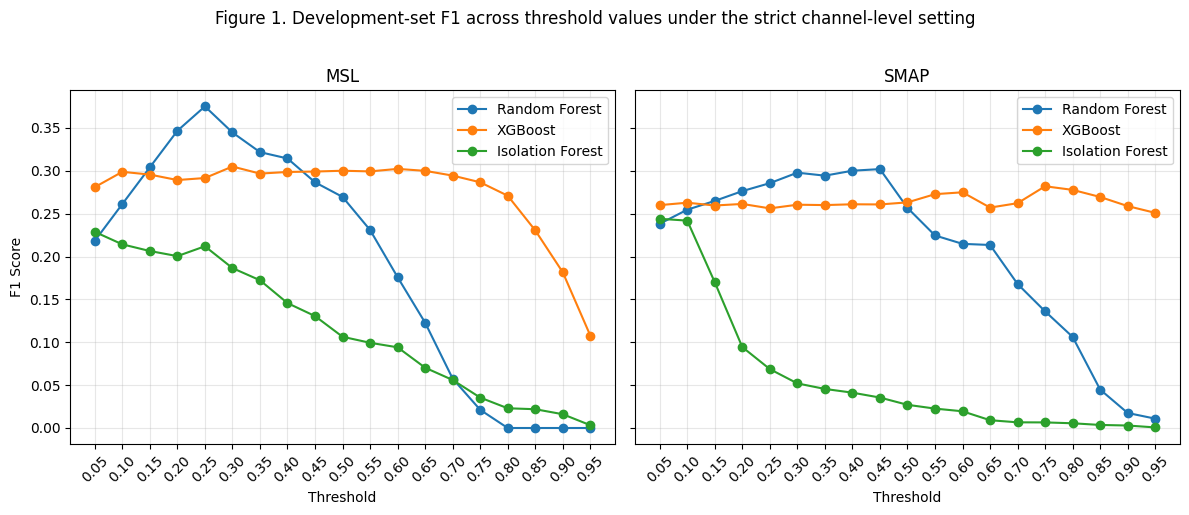

In [ ]:
# Threshold-versus-F1 curves for the strict channel-level setting

# Strict MSL threshold sweep tables
msl_rf_df = rf_threshold_df
msl_xgb_df = xgb_threshold_df
msl_if_df = if_threshold_df

# Strict SMAP threshold sweep tables
smap_rf_df = smap_rf_threshold_df
smap_xgb_df = smap_xgb_threshold_df
smap_if_df = smap_if_threshold_df

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panel (a): MSL
axes[0].plot(msl_rf_df["threshold"], msl_rf_df["f1"], marker="o", label="Random Forest")
axes[0].plot(msl_xgb_df["threshold"], msl_xgb_df["f1"], marker="o", label="XGBoost")
axes[0].plot(msl_if_df["threshold"], msl_if_df["f1"], marker="o", label="Isolation Forest")

axes[0].set_title("MSL")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("F1 Score")
axes[0].set_xticks(msl_rf_df["threshold"])
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Panel (b): SMAP
axes[1].plot(smap_rf_df["threshold"], smap_rf_df["f1"], marker="o", label="Random Forest")
axes[1].plot(smap_xgb_df["threshold"], smap_xgb_df["f1"], marker="o", label="XGBoost")
axes[1].plot(smap_if_df["threshold"], smap_if_df["f1"], marker="o", label="Isolation Forest")

axes[1].set_title("SMAP")
axes[1].set_xlabel("Threshold")
axes[1].set_xticks(smap_rf_df["threshold"])
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle("Figure 1. Development-set F1 across threshold values under the strict channel-level setting", y=1.02)
plt.tight_layout()
plt.savefig("figure1_threshold_f1_strict.png", dpi=300, bbox_inches="tight")
plt.show()